# NLP Project 10: Banking Complaint Analysis





## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set(style="whitegrid")
%matplotlib inline


## Step 2: Collect Banking Complaint Data

In [3]:
df = pd.read_csv(r"C:\files\AU jupyter\NLP\complaints.csv")
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna(subset=["narrative"]).reset_index(drop=True)
df.head()


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162411 entries, 0 to 162410
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    162411 non-null  object
 1   narrative  162411 non-null  object
dtypes: object(2)
memory usage: 2.5+ MB


In [5]:
df["product"].value_counts()


product
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64

## Step 3: Preprocess Complaint Text

Clean the narrative text (lowercase, remove punctuation/numbers, remove stopwords).

In [6]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

df["clean_narrative"] = df["narrative"].apply(clean_text)
df[["narrative", "clean_narrative"]].head()


,narrative,clean_narrative
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message sent friday pdt subject fina...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


## Step 4: Categorize Customer Complaints

Train a text classification model (TF-IDF + Logistic Regression) to automatically categorize complaints into product categories. A sample is used here for speed; increase `SAMPLE_SIZE` for more data.

In [7]:
SAMPLE_SIZE = 20000
data = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    data["clean_narrative"], data["product"], test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [8]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.851
                     precision    recall  f1-score   support

        credit_card       0.79      0.73      0.76       382
   credit_reporting       0.88      0.93      0.90      2231
    debt_collection       0.79      0.65      0.71       575
mortgages_and_loans       0.82      0.82      0.82       474
     retail_banking       0.83      0.88      0.85       338

           accuracy                           0.85      4000
          macro avg       0.82      0.80      0.81      4000
       weighted avg       0.85      0.85      0.85      4000



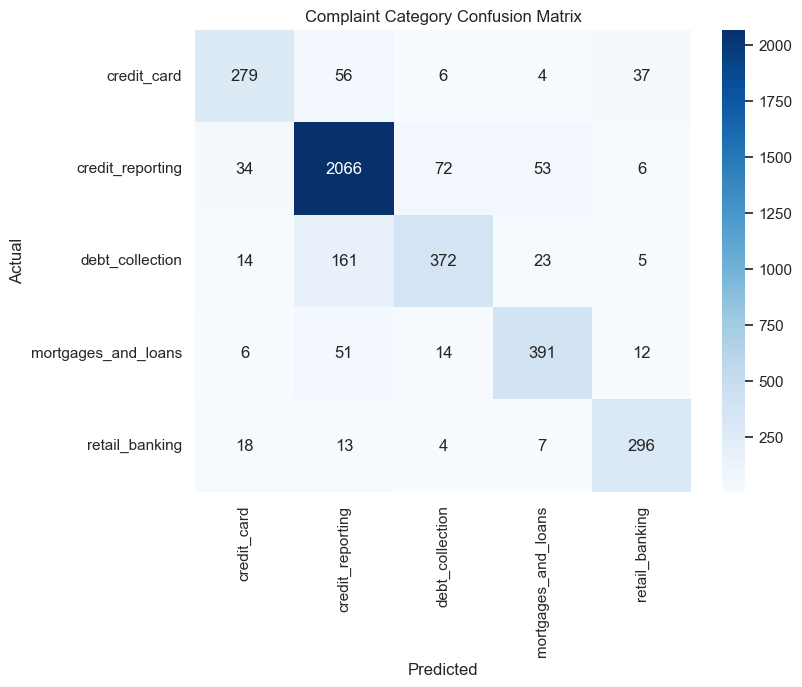

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Complaint Category Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Step 5: Identify Frequent Banking Issues

Check how complaint volume is distributed across categories, and find the most common words overall and in the top category.

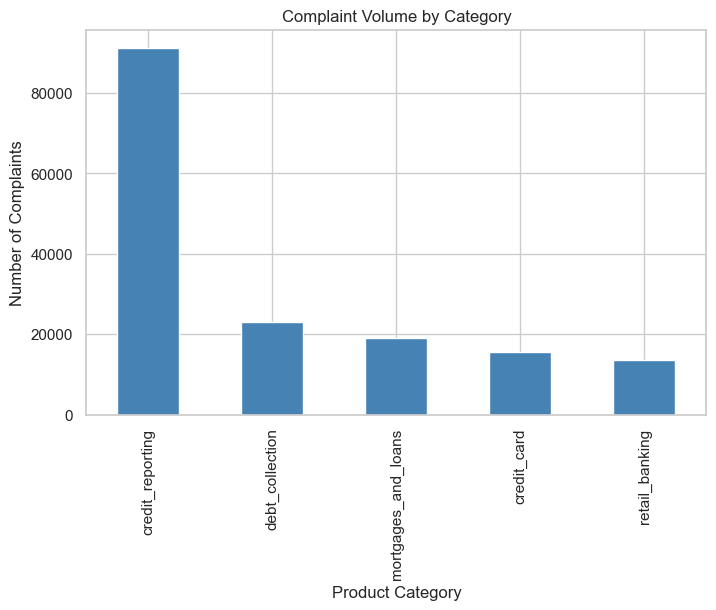

In [10]:
category_counts = df["product"].value_counts()

plt.figure(figsize=(8,5))
category_counts.plot(kind="bar", color="steelblue")
plt.title("Complaint Volume by Category")
plt.ylabel("Number of Complaints")
plt.xlabel("Product Category")
plt.show()


In [11]:
all_words = " ".join(df["clean_narrative"].sample(n=min(20000, len(df)), random_state=42)).split()
word_freq = Counter(all_words)
common_issues = word_freq.most_common(20)
common_issues


[('credit', 39527),
 ('account', 39108),
 ('report', 22039),
 ('information', 17912),
 ('payment', 15677),
 ('reporting', 11399),
 ('time', 10274),
 ('would', 9775),
 ('company', 9615),
 ('day', 9518),
 ('loan', 9129),
 ('debt', 9050),
 ('received', 8829),
 ('card', 8724),
 ('letter', 8552),
 ('bank', 8417),
 ('consumer', 7707),
 ('dispute', 7559),
 ('sent', 7423),
 ('never', 7239)]

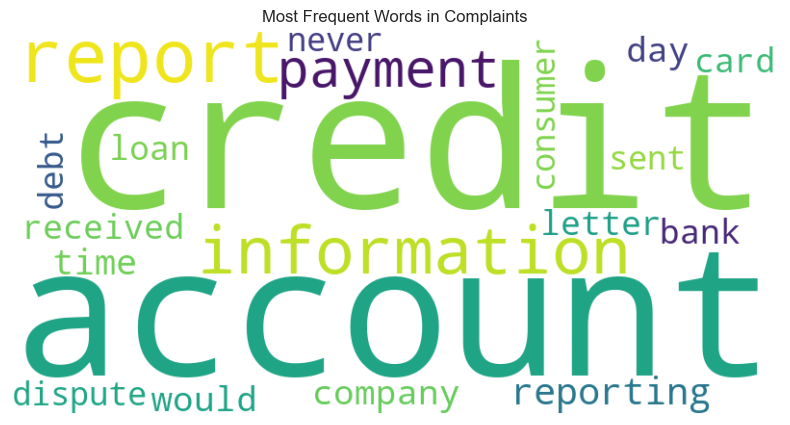

In [12]:
wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(dict(common_issues))

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Complaints")
plt.show()


## Step 6: Generate Analytical Report

In [13]:
total_complaints = len(df)
top_category = category_counts.idxmax()
top_category_pct = (category_counts.max() / total_complaints) * 100
model_accuracy = accuracy_score(y_test, y_pred)

print(f"Total Complaints Analyzed: {total_complaints}")
print(f"Number of Categories: {df['product'].nunique()}")
print(f"Most Frequent Category: {top_category} ({top_category_pct:.1f}% of complaints)")
print(f"Classification Model Accuracy: {model_accuracy:.2%}")
print("\nTop Recurring Issue Keywords:")
for word, freq in common_issues[:10]:
    print(f"- {word} ({freq})")


Total Complaints Analyzed: 162411
Number of Categories: 5
Most Frequent Category: credit_reporting (56.1% of complaints)
Classification Model Accuracy: 85.10%

Top Recurring Issue Keywords:
- credit (39527)
- account (39108)
- report (22039)
- information (17912)
- payment (15677)
- reporting (11399)
- time (10274)
- would (9775)
- company (9615)
- day (9518)


### Key Takeaways

- Complaint volume by category shows which banking products generate the most customer issues.
- The classification model can automatically route new complaints to the right category, reducing manual review time.
- Frequent keywords highlight the recurring root causes behind complaints (e.g. billing, fraud, payment delays).
- The bank can prioritize process improvements for the top complaint category and monitor keyword trends over time.
